# Lab: Relationships in Space and Time

Florida red tide is caused primarily by high concentrations of the microscopic alga *Karenia brevis*. The organism can produce toxins that harm marine life and cause respiratory irritation near affected shorelines. A bloom does not remain in one fixed place: winds and currents can move and disperse it while its concentration changes.

This lab examines part of the unusually long 2017–2019 Florida red-tide bloom. From June through November 2018, documented bloom concentrations expanded beyond southwest Florida and were detected in the Panhandle and, for part of the period, along the Atlantic coast.

## Learning goals

By the end of this lab, you should be able to:

- prepare and check a temporal feature;
- summarize observations by month;
- create and interpret an interactive time-series plot;
- map observations using exact latitude and longitude coordinates;
- animate spatial observations through time with Plotly Express; and
- distinguish documented sample locations from the complete extent of an environmental event.

## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response. Do not submit an AI response that you cannot explain.

## Dataset

The course dataset was prepared from the Florida Fish and Wildlife Conservation Commission's [Historic Harmful Algal Bloom Events 2015–2023 GIS layer](https://gis.myfwc.com/mapping/rest/services/Open_Data/Historic_Harmful_Algal_Bloom_Events_2015___2023/MapServer/12). It contains **7,292 water samples** collected from June 1 through November 30, 2018.

These are sampling records, not a continuous measurement of every part of Florida's coastal water. Sampling included routine monitoring, research, and additional event-response sampling when a bloom was suspected or already known.

# Step 1: Question

> **How did the location and concentration of documented Florida red tide change from June through November 2018?**

**During which month do you predict the greatest share of samples reached bloom concentration?**

Your answer: October 2018, near the peak of the bloom.

**Where around Florida do you predict bloom concentrations will appear by the end of this period?**

Your answer: Starting in southwest Florida and spreading up the Gulf coast toward the Panhandle, with some reaching the Atlantic coast.

# Step 2: Data

## 1. Import the libraries

Import Pandas and Plotly Express using their conventional aliases.

In [14]:
# Write your code here.
import pandas as pd
import plotly.express as px

## 2. Read the data

Read `data/florida_red_tide_samples_june_november_2018.csv` into a DataFrame named `red_tide`. Use `parse_dates=["sample_date"]` so Pandas stores the sample date as a datetime rather than text.

In [15]:
# Write your code here.
red_tide = pd.read_csv("data/florida_red_tide_samples_june_november_2018.csv", parse_dates=["sample_date"])

## 3. Preview and inspect the DataFrame

Display the first five rows, last five rows, stored data types, and missing-value counts.

In [16]:
# Write your code here.
display(red_tide.head())
display(red_tide.tail())
red_tide.info()
red_tide.isnull().sum()

,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
0,2018-06-01,Red Reef Park Beach,26.36043,-80.06847,0.5,0.0,Not present/background
1,2018-06-01,Gumbo Limbo Nature Center (Lake Wyman),26.36751,-80.07118,0.5,0.0,Not present/background
2,2018-06-01,Bay Dock (Sarasota Bay),27.33160,-82.57790,0.5,5000.0,Very low
3,2018-06-01,New Pass Dock (Sarasota Bay),27.33375,-82.57938,0.5,1000.0,Not present/background
4,2018-06-01,Dixie Highway Bridge; E of (Indian River),27.85566,-80.49085,1.3,0.0,Not present/background


,sample_date,location,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter,abundance_category
7287,2018-11-29,Brooks Bridge; W of (Santa Rosa Sound),30.400800,-86.600800,0.1,0.0,Not present/background
7288,2018-11-30,Gasparilla Island; 10 mi W of,26.722583,-82.366933,0.5,20667.0,Low
7289,2018-11-30,Gasparilla Island; 13 mi W of,26.760700,-82.475550,0.5,391020.0,Medium
7290,2018-11-30,Bay Dock (Sarasota Bay),27.331600,-82.577900,0.5,534000.0,Medium
7291,2018-11-30,New Pass Dock (Sarasota Bay),27.333750,-82.579380,0.5,274000.0,Medium


<class 'pandas.DataFrame'>
RangeIndex: 7292 entries, 0 to 7291
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   sample_date                     7292 non-null   datetime64[us]
 1   location                        7292 non-null   str           
 2   latitude                        7292 non-null   float64       
 3   longitude                       7292 non-null   float64       
 4   sample_depth_m                  7259 non-null   float64       
 5   karenia_brevis_cells_per_liter  7292 non-null   float64       
 6   abundance_category              7292 non-null   str           
dtypes: datetime64[us](1), float64(4), str(2)
memory usage: 714.8 KB


sample_date                        0
location                           0
latitude                           0
longitude                          0
sample_depth_m                    33
karenia_brevis_cells_per_liter     0
abundance_category                 0
dtype: int64

### Data dictionary

| Feature | Meaning |
| --- | --- |
| `sample_date` | Calendar date on which the water sample was collected |
| `location` | Description or name of the sampling location |
| `latitude` | Sample latitude in decimal degrees north |
| `longitude` | Sample longitude in decimal degrees; values west of the prime meridian are negative |
| `sample_depth_m` | Sampling depth in meters |
| `karenia_brevis_cells_per_liter` | Number of *Karenia brevis* cells measured per liter of water |
| `abundance_category` | FWC concentration category calculated from the cell count |

The FWC categories are:

- **Not present/background:** 0–1,000 cells per liter
- **Very low:** over 1,000–10,000
- **Low:** over 10,000–100,000
- **Medium:** over 100,000–1,000,000
- **High:** over 1,000,000

For this lab, a sample is at **bloom concentration** when it contains at least 100,000 cells per liter.

Complete the table using the data dictionary, `.info()`, and `.isnull().sum()`.

| Feature | Feature type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `sample_date` | Temporal | datetime64 | 0 |
| `location` | Categorical | str | 0 |
| `latitude` | Quantitative | float64 | 0 |
| `longitude` | Quantitative | float64 | 0 |
| `sample_depth_m` | Quantitative | float64 | 33 |
| `karenia_brevis_cells_per_liter` | Quantitative | float64 | 0 |
| `abundance_category` | Categorical | str | 0 |

**What does one row represent?**

Your answer: One water sample collected at one location on one date, with its measured cell count and category.

**Why can the same location appear in more than one row?**

Your answer: Locations were sampled repeatedly over time, so each visit is its own row.

# Step 3: Operation

## 4. Sort the samples by date

Sort `red_tide` by `sample_date`. Use `inplace=True` to modify the existing DataFrame rather than creating another one.

In [17]:
# Write your code here.
red_tide.sort_values(by="sample_date", inplace=True)

## 5. Create monthly time features

Create `month` by using datetime methods to convert each `sample_date` to a monthly period and then back to a timestamp. The resulting timestamp represents the first day of its month and can be sorted chronologically.

Then create `month_label` with `.dt.strftime("%B %Y")`. This creates readable labels such as `June 2018` for the animation.

In [18]:
# Write your code here.
red_tide["month"] = red_tide["sample_date"].dt.to_period("M").dt.to_timestamp()
red_tide["month_label"] = red_tide["sample_date"].dt.strftime("%B %Y")

## 6. Identify samples at bloom concentration

Create a Boolean feature named `bloom_level` that is `True` when `karenia_brevis_cells_per_liter` is at least 100,000 and `False` otherwise.

In [19]:
# Write your code here.
red_tide["bloom_level"] = red_tide["karenia_brevis_cells_per_liter"] >= 100000

## 7. Create a monthly summary

Group the records by `month` and use `.agg()` to calculate:

- `total_samples`: the number of cell-count records in each month; and
- `bloom_samples`: the sum of `bloom_level` in each month.

Summing works because Pandas evaluates `True` as 1 and `False` as 0. Use `.reset_index()` to return `month` to a regular column.

Then calculate `percent_bloom` as the number of bloom samples divided by the total number of samples, multiplied by 100. Display `monthly_summary`.

In [20]:
# Write your code here.
monthly_summary = red_tide.groupby("month").agg(total_samples=("karenia_brevis_cells_per_liter", "count"), bloom_samples=("bloom_level", "sum")).reset_index()
monthly_summary["percent_bloom"] = monthly_summary["bloom_samples"] / monthly_summary["total_samples"] * 100
monthly_summary

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


## 8. Prepare the map data

To keep the spatial figures readable, create `map_data` containing samples with more than 10,000 cells per liter. Use `.copy()` because `map_data` will be a separate DataFrame used for the figures.

Create `month_order` from the unique `month_label` values. Because the rows were sorted first, the labels will be in chronological order. Also create `abundance_order` containing `Low`, `Medium`, and `High` in that order.

Samples at or below 10,000 cells per liter remain in `red_tide` and in the monthly summary; they are omitted only from the maps.

In [21]:
# Write your code here.
map_data = red_tide[red_tide["karenia_brevis_cells_per_liter"] > 10000].copy()

month_order = list(map_data["month_label"].unique())
abundance_order = ["Low", "Medium", "High"]

# Step 4: Check

## 9. Check the prepared data

Display:

- the number of rows;
- the earliest and latest dates;
- the number of unique months;
- missing-value counts for the date, coordinates, cell count, and depth; and
- descriptive statistics for latitude, longitude, depth, and cell count.

In [22]:
# Write your code here.
print("Rows:", len(red_tide))
print("Earliest Date:", red_tide["sample_date"].min())
print("Latest Date:", red_tide["sample_date"].max())
print("Unique Months:", red_tide["month"].nunique())
print()
print(red_tide[["sample_date", "latitude", "longitude", "karenia_brevis_cells_per_liter", "sample_depth_m"]].isnull().sum())

red_tide[["latitude", "longitude", "sample_depth_m", "karenia_brevis_cells_per_liter"]].describe()

Rows: 7292
Earliest Date: 2018-06-01 00:00:00
Latest Date: 2018-11-30 00:00:00
Unique Months: 6

sample_date                        0
latitude                           0
longitude                          0
karenia_brevis_cells_per_liter     0
sample_depth_m                    33
dtype: int64


,latitude,longitude,sample_depth_m,karenia_brevis_cells_per_liter
count,7292.000000,7292.000000,7259.000000,7.292000e+03
mean,27.428306,-82.253707,1.326353,5.472636e+05
std,1.297599,1.452258,4.368422,3.276337e+06
min,24.455000,-87.325914,0.000000,0.000000e+00
25%,26.576700,-82.683950,0.500000,0.000000e+00
50%,27.308970,-82.337920,0.500000,0.000000e+00
75%,28.047500,-81.408525,0.500000,3.066700e+04
max,30.701200,-79.948800,71.000000,9.000000e+07


**Why do the 33 missing depth values not require us to remove those records from this analysis?**

Your answer: Depth is not used in the time series or the maps, so a missing depth doesn't affect this analysis. The features we rely on are all complete.

## 10. Check the aggregation

Display `monthly_summary`, then compare the sum of `total_samples` with the number of rows in `red_tide`. Compare the sum of `bloom_samples` with the sum of `bloom_level` in the original DataFrame.

In [23]:
# Write your code here.
display(monthly_summary)

print("Sum of total_samples:", monthly_summary["total_samples"].sum())
print("Rows in red_tide:", len(red_tide))
print("Sum of bloom_samples:", monthly_summary["bloom_samples"].sum())
print("Sum of bloom_level:", red_tide["bloom_level"].sum())

,month,total_samples,bloom_samples,percent_bloom
0,2018-06-01,991,119,12.008073
1,2018-07-01,865,126,14.566474
2,2018-08-01,1236,364,29.449838
3,2018-09-01,1196,238,19.899666
4,2018-10-01,1855,290,15.633423
5,2018-11-01,1149,289,25.152306


Sum of total_samples: 7292
Rows in red_tide: 7292
Sum of bloom_samples: 1426
Sum of bloom_level: 1426


**What kind of preparation error could be revealed if either pair of totals did not match?**

Your answer: A mismatch would signal a grouping or filtering error, like dropped rows, double-counting, or samples missing a month, meaning the summary didn't capture every record correctly.

# Step 5: Evidence

## 11. Plot the monthly percentage at bloom concentration

Use `px.line()` with `monthly_summary` to plot `month` against `percent_bloom`. Show markers and add a question-focused title and readable axis labels.

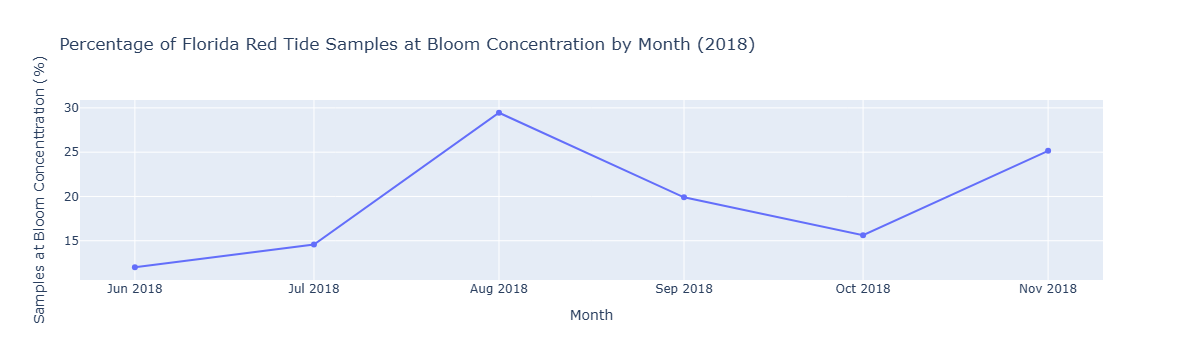

In [24]:
# Write your code here.
fig = px.line(monthly_summary, x="month", y="percent_bloom", markers=True, title="Percentage of Florida Red Tide Samples at Bloom Concentration by Month (2018)", labels={"month": "Month", "percent_bloom": "Samples at Bloom Concenttration (%)"})
fig.show()

**During which month was the percentage of samples at bloom concentration highest?**

Your answer: August 2018, at about 29.4%.

**What temporal pattern do you observe from June through November?**

Your answer: The bloom percentage climbed from June to a peak in August, dropped through September and October, then rose again in November. It was not a steady rise.

## 12. Map the documented sample locations

Create a static `px.scatter_map()` using `map_data`.

- Use the exact `latitude` and `longitude` features.
- Map `abundance_category` to color.
- Use `location` as the hover name.
- Include `sample_date` and the cell count in `hover_data`.
- Use `abundance_order` in `category_orders`.
- Choose three ordered colors for Low, Medium, and High abundance.
- Use `zoom=4.5`, center the map at latitude 27.7 and longitude -82.3, use the `open-street-map` style, and set `height=650`.

The `abundance_category` values were already defined in the course dataset from the FWC cell-count ranges introduced in the data dictionary:

- **Low:** over 10,000–100,000 cells per liter
- **Medium:** over 100,000–1,000,000 cells per liter
- **High:** over 1,000,000 cells per liter

Because `map_data` contains only samples above 10,000 cells per liter, these are the three categories that appear in the map legend. You do not need to calculate the categories again.



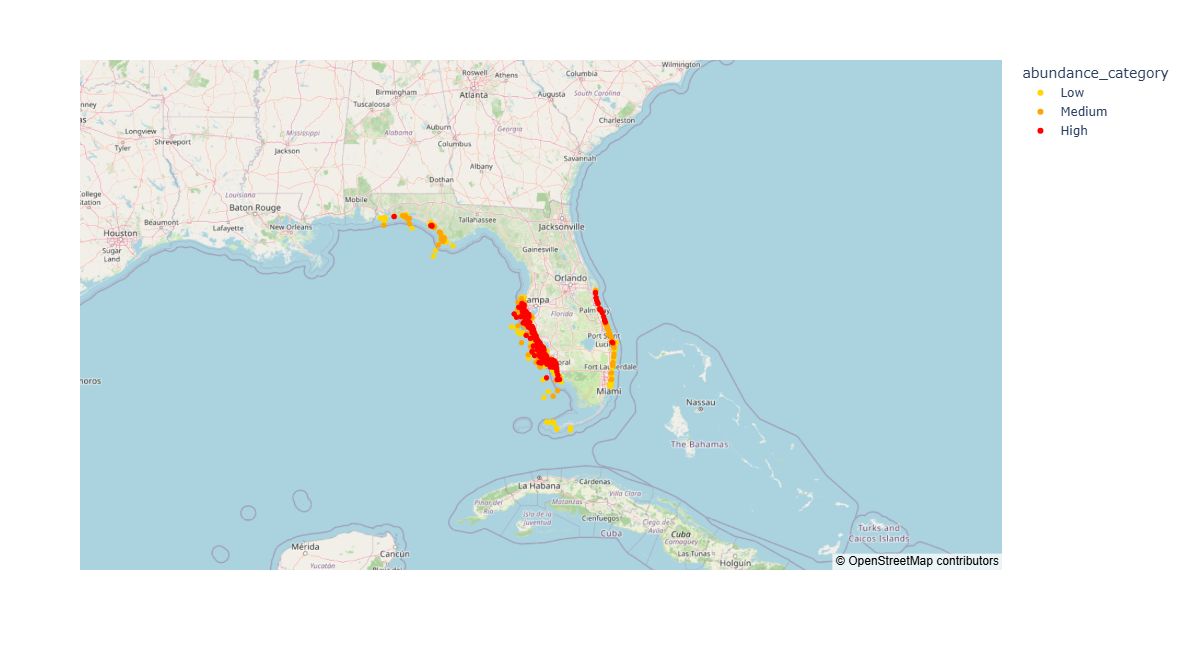

In [25]:
# Write your code here.
fig = px.scatter_map(map_data, lat="latitude", lon="longitude", color="abundance_category", 
                    hover_name="location", hover_data=["sample_date", "karenia_brevis_cells_per_liter"], 
                    category_orders={"abundance_category": abundance_order}, color_discrete_sequence=["gold", "orange", "red"], 
                    zoom=4.5, center={"lat": 27.7, "lon": -82.3}, map_style="open-street-map", height=650)
fig.show()

**What spatial pattern is visible in the static map?**

Your answer: Samples concentrate along Florida's southwest Gulf coast from Tampa down to Fort Myers, where most of the high concentration points sit. Lighter samples appear in the Panhandle and along the Atlantic coast.

**What important temporal information is difficult to recover from the static map?**

Your answer: The map shows all six months at once, so you can't tell when each area was affected or how the bloom moved over time.

## 13. Animate the documented sample locations

Re-create the spatial figure with `animation_frame="month_label"`. Add the chronological `month_order` to `category_orders` so the slider follows June through November.

Keep the map center, zoom, height, category order, and colors fixed. This makes changes among frames easier to interpret as changes in the observations rather than changes in the display.

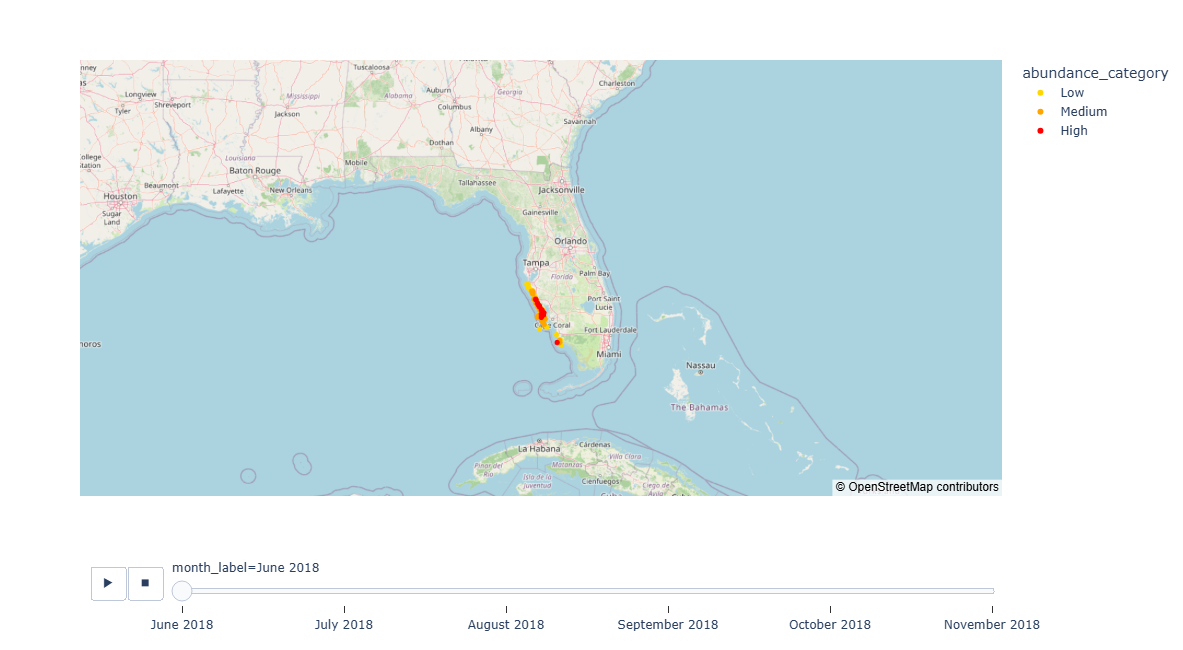

In [26]:
# Write your code here.
fig = px.scatter_map(map_data, lat="latitude", lon="longitude", color="abundance_category", 
                    hover_name="location", hover_data=["sample_date", "karenia_brevis_cells_per_liter"], 
                    category_orders={"abundance_category": abundance_order, "month_label": month_order}, color_discrete_sequence=["gold", "orange", "red"],
                    animation_frame="month_label", zoom=4.5, center={"lat": 27.7, "lon": -82.3}, map_style="open-street-map", height=650)
fig.show()

**How did the documented bloom's geographic pattern change from June through November?**

Your answer: It started on the southwest Gulf coast, then spread to the Panhandle and Atlantic coast later while staying strongest in the southwest.

**Which figure makes the timing of geographic expansion easiest to see?**

Your answer: The animated map, since the slider shows when each area was affected.

# Step 6: Conclusion and limitation

**Write a concise conclusion that answers the research question using evidence from both the time-series plot and the animated map.**

Your answer: The bloom peaked in August, dipped in the fall, and rose again in November. The maps show it centered on the southwest Gulf coast and spreading to the Panhandle and Atlantic coast. Both intensity and location changed over the period.

**Why does the animation show documented sample locations rather than the complete geographic boundary of the bloom?**

Your answer: The data is individual samples, not a full survey. It shows where water was tested, and not the bloom's true extent.

**Why should the monthly percentages not be interpreted as the percentage of all Florida coastal water affected by red tide?**

Your answer: The percentages cover sampled water only, and sampling often targeted suspected blooms. They don't represent the whole coast.

## AI-use reflection

**State whether you used an AI tool and, if you did, identify one suggestion you checked and explain what you accepted, modified, or rejected.**

Your answer: Yes, I used Claude AI to check my code and interpretations. One thing I confirmed was summing the Boolean "bloom_level" to count bloom samples. I checked every result against the notebook output myself.

## Submission checklist

- Run every code cell from top to bottom.
- Use all requested DataFrame and feature names.
- Complete every written-response cell.
- Give every figure a readable title and axis labels when axes are present.
- Support the conclusion with evidence from the figures and calculated values.
- Distinguish sample locations from the complete extent of the bloom.
- Keep the notebook organized and readable.
- Submit the completed notebook by the deadline.